In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from matplotlib.patches import Rectangle

import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [ ]:
data = np.loadtxt('unsolicited-data.txt')  # replace with your actual file path
timestamps = data[:, 0]
values = data[:, 1]

# Define row range to plot (Python indexing: inclusive start, exclusive end)
start_row = 0    # change as needed
end_row = 2000   # change as needed

# Slice data
timestamps = data[start_row:end_row, 0]
values = data[start_row:end_row, 1]

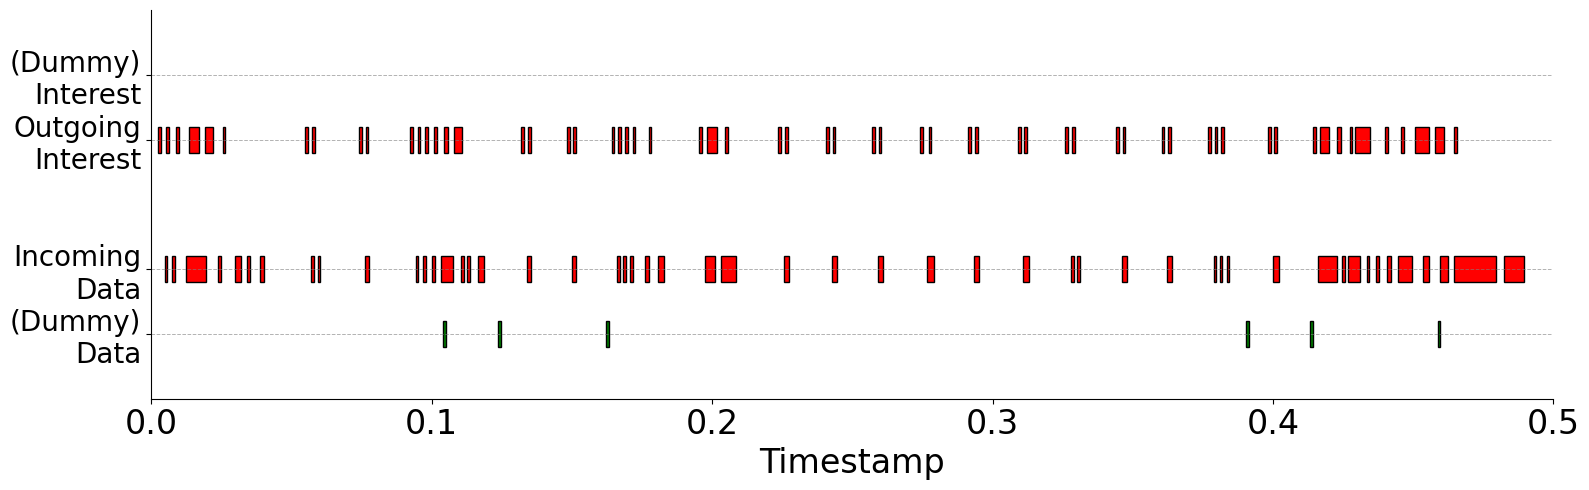

In [15]:
# Configurable tolerance for merging
timestamp_tolerance = 0.002

# Grouping: find packets close in timestamp and same y
groups = []
for idx, (x, y) in enumerate(zip(timestamps, values), start=start_row):
    matched = False
    for group in groups:
        gx_list, gy, indices = group
        if abs(x - gx_list[-1]) <= timestamp_tolerance and y == gy:
            gx_list.append(x)
            indices.append(idx)
            matched = True
            break
    if not matched:
        groups.append(([x], y, [idx]))

# Plot
fig, ax = plt.subplots(figsize=(16, 5))

# Track x extents
all_xmins = []
all_xmaxs = []

for gx_list, gy, indices in groups:
    xmin = min(gx_list)
    xmax = max(gx_list)
    
    # Set different minimum widths based on gy
    min_width = 0.001 if abs(gy) == 2 else 0.001
    width = max(xmax - xmin, min_width)

    height = 0.4
    all_xmins.append(xmin)
    all_xmaxs.append(xmax)

    color = 'red' if abs(gy) == 1 else 'green'

    rect = Rectangle((xmin, gy - height / 2), width, height,
                     facecolor=color, edgecolor='black', zorder=2)
    ax.add_patch(rect)

# --- Set axis limits ---
x_padding = 0.0005
global_xmin = min(all_xmins) - x_padding
global_xmax = max(all_xmaxs) + x_padding
ax.set_xlim(global_xmin, global_xmax)
ax.set_ylim(-3, 3)

# --- Axis labels and title ---
ax.set_xlabel("Timestamp", fontsize=24)

# --- Tick label size ---
ax.tick_params(axis='both', labelsize=24)

# --- Add 0.0 tick to x-axis ---
xticks = list(ax.get_xticks())
if 0.0 not in xticks:
    xticks.append(0.0)
xticks = sorted(set(xticks))
ax.set_xticks(xticks)

# --- Custom y-ticks (only ±1, ±2) ---
ax.set_yticks([-2, -1, 1, 2])
ax.set_yticklabels([
    "(Dummy)\nData",
    "Incoming\nData",
    "Outgoing\nInterest",
    "(Dummy)\nInterest"
], fontsize=20)

# --- Grid lines only at ±1, ±2 ---
for y in [-2, -1, 1, 2]:
    ax.axhline(y, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)

# --- Clean up plot frame ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Render ---
plt.tight_layout()
plt.savefig("unsolicited-data.pdf", format='pdf')
plt.show()

In [ ]:
data = np.loadtxt('unsatisfied-interest.txt')  # replace with your actual file path
timestamps = data[:, 0]
values = data[:, 1]

# Define row range to plot (Python indexing: inclusive start, exclusive end)
start_row = 0    # change as needed
end_row = 500   # change as needed

# Slice data
timestamps = data[start_row:end_row, 0]
values = data[start_row:end_row, 1]

In [ ]:
# Configurable tolerance for merging
timestamp_tolerance = 0.008

# Grouping: find packets close in timestamp and same y
groups = []
for idx, (x, y) in enumerate(zip(timestamps, values), start=start_row):
    matched = False
    for group in groups:
        gx_list, gy, indices = group
        if abs(x - gx_list[-1]) <= timestamp_tolerance and y == gy:
            gx_list.append(x)
            indices.append(idx)
            matched = True
            break
    if not matched:
        groups.append(([x], y, [idx]))

# Plot
fig, ax = plt.subplots(figsize=(16, 5))

# Track x extents
all_xmins = []
all_xmaxs = []

for gx_list, gy, indices in groups:
    xmin = min(gx_list)
    xmax = max(gx_list)
    
    # Set different minimum widths based on gy
    min_width = 0.001 if abs(gy) == 2 else 0.001
    width = max(xmax - xmin, min_width)

    height = 0.4
    all_xmins.append(xmin)
    all_xmaxs.append(xmax)

    color = 'red' if abs(gy) == 1 else 'green'

    rect = Rectangle((xmin, gy - height / 2), width, height,
                     facecolor=color, edgecolor='black', zorder=2)
    ax.add_patch(rect)

# --- Set axis limits ---
x_padding = 0.0005
global_xmin = min(all_xmins) - x_padding
global_xmax = max(all_xmaxs) + x_padding
ax.set_xlim(global_xmin, global_xmax)
ax.set_ylim(-3, 3)

# --- Axis labels and title ---
ax.set_xlabel("Timestamp", fontsize=24)

# --- Tick label size ---
ax.tick_params(axis='both', labelsize=24)

# --- Add 0.0 tick to x-axis ---
xticks = list(ax.get_xticks())
if 0.0 not in xticks:
    xticks.append(0.0)
xticks = sorted(set(xticks))
ax.set_xticks(xticks)

# --- Custom y-ticks (only ±1, ±2) ---
ax.set_yticks([-2, -1, 1, 2])
ax.set_yticklabels([
    "(Dummy)\nData",
    "Incoming\nData",
    "Outgoing\nInterest",
    "(Dummy)\nInterest"
], fontsize=20)

# --- Grid lines only at ±1, ±2 ---
for y in [-2, -1, 1, 2]:
    ax.axhline(y, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)

# --- Clean up plot frame ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Render ---
plt.tight_layout()
plt.savefig("unsatistifed-interest.pdf", format='pdf')
plt.show()